In [1]:
sales_data = [
    (1001, "Hyderabad", "Electronics", "Laptop", 2, 65000, "Completed"),
    (1002, "Bangalore", "Electronics", "Mobile", 3, 25000, "Completed"),
    (1003, "Mumbai", "Furniture", "Chair", 5, 3500, "Pending"),
    (1004, "Delhi", "Furniture", "Table", 2, 12000, "Completed"),
    (1005, "Chennai", "Fashion", "Shoes", 4, 2500, "Completed"),
    (1006, "Pune", "Fashion", "Watch", 1, 8000, "Cancelled"),
    (1007, "Hyderabad", "Electronics", "TV", 1, 45000, "Completed"),
    (1008, "Mumbai", "Electronics", "Laptop", 2, 65000, "Completed"),
    (1009, "Delhi", "Furniture", "Chair", 3, 3500, "Pending"),
    (1010, "Bangalore", "Fashion", "Shoes", 5, 2500, "Completed"),
    (1011, "Chennai", "Electronics", "Mobile", 4, 25000, "Completed"),
    (1012, "Hyderabad", "Fashion", "Watch", 2, 8000, "Completed")
]


In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Sales DataFrame") \
    .getOrCreate()

In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Sales DataFrame") \
    .getOrCreate()

columns = ["order_id", "city", "category", "product", "quantity", "price", "status"]

df = spark.createDataFrame(sales_data, columns)

df.show()

+--------+---------+-----------+-------+--------+-----+---------+
|order_id|     city|   category|product|quantity|price|   status|
+--------+---------+-----------+-------+--------+-----+---------+
|    1001|Hyderabad|Electronics| Laptop|       2|65000|Completed|
|    1002|Bangalore|Electronics| Mobile|       3|25000|Completed|
|    1003|   Mumbai|  Furniture|  Chair|       5| 3500|  Pending|
|    1004|    Delhi|  Furniture|  Table|       2|12000|Completed|
|    1005|  Chennai|    Fashion|  Shoes|       4| 2500|Completed|
|    1006|     Pune|    Fashion|  Watch|       1| 8000|Cancelled|
|    1007|Hyderabad|Electronics|     TV|       1|45000|Completed|
|    1008|   Mumbai|Electronics| Laptop|       2|65000|Completed|
|    1009|    Delhi|  Furniture|  Chair|       3| 3500|  Pending|
|    1010|Bangalore|    Fashion|  Shoes|       5| 2500|Completed|
|    1011|  Chennai|Electronics| Mobile|       4|25000|Completed|
|    1012|Hyderabad|    Fashion|  Watch|       2| 8000|Completed|
+--------+

In [5]:
columns = ["order_id", "city", "category", "product", "quantity", "price", "status"]

df = spark.createDataFrame(sales_data, columns)

from pyspark.sql.functions import col

df = df.withColumn("revenue", col("quantity") * col("price"))

display(df)

DataFrame[order_id: bigint, city: string, category: string, product: string, quantity: bigint, price: bigint, status: string, revenue: bigint]

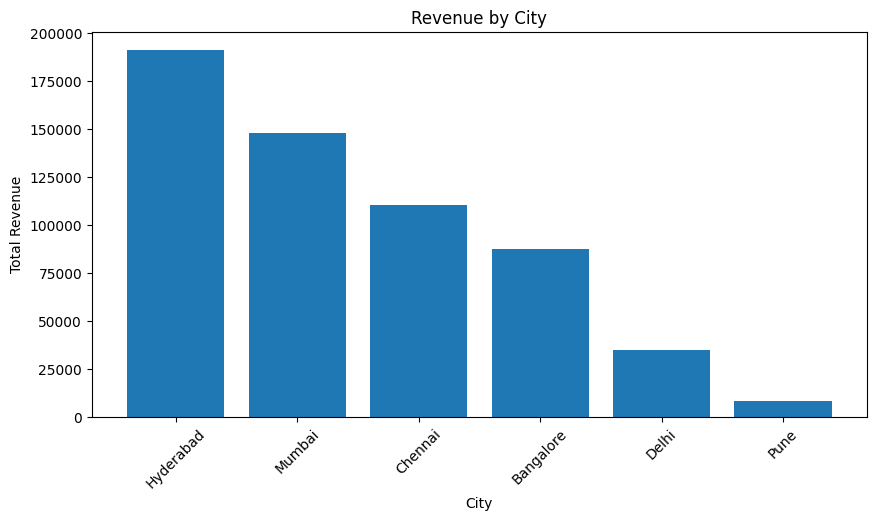

In [6]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum, col

city_revenue_df = df.groupBy("city").agg(
    sum("revenue").alias("total_revenue")
).orderBy(col("total_revenue").desc())

city_pd = city_revenue_df.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(city_pd["city"], city_pd["total_revenue"])
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.title("Revenue by City")
plt.xticks(rotation=45)
plt.show()

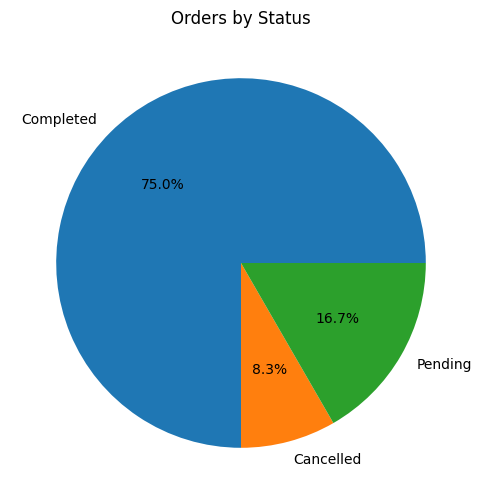

In [11]:
status_df = df.groupBy("status").count()

status_pd = status_df.toPandas()

plt.figure(figsize=(6, 6))
plt.pie(
    status_pd["count"],
    labels=status_pd["status"],
    autopct="%1.1f%%"
)
plt.title("Orders by Status")
plt.show()

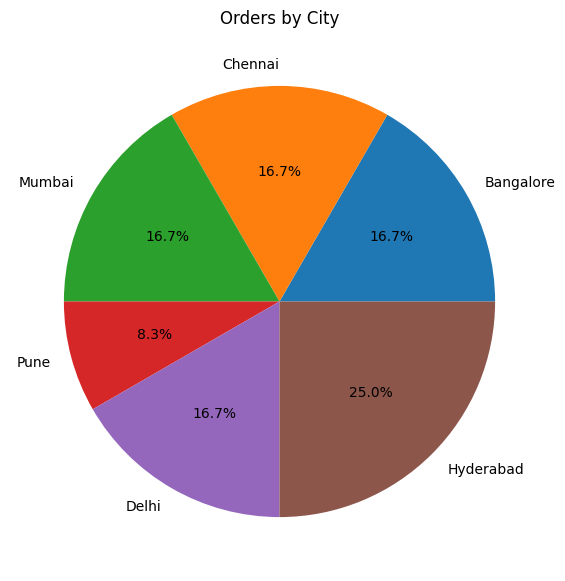

In [12]:
city_df = df.groupBy("city").count()

city_pd = city_df.toPandas()

plt.figure(figsize=(7, 7))
plt.pie(
    city_pd["count"],
    labels=city_pd["city"],
    autopct="%1.1f%%"
)
plt.title("Orders by City")
plt.show()

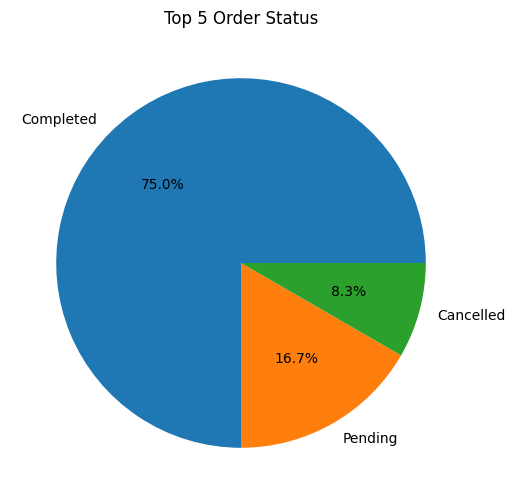

In [13]:
status_df = df.groupBy("status").count().orderBy("count", ascending=False).limit(5)

status_pd = status_df.toPandas()

plt.figure(figsize=(6, 6))
plt.pie(
    status_pd["count"],
    labels=status_pd["status"],
    autopct="%1.1f%%"
)
plt.title("Top 5 Order Status")
plt.show()

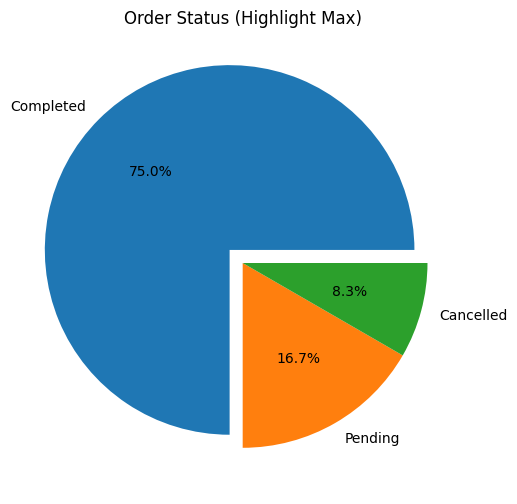

In [14]:
explode = [0.1 if i == status_pd["count"].idxmax() else 0 for i in range(len(status_pd))]

plt.figure(figsize=(6, 6))
plt.pie(
    status_pd["count"],
    labels=status_pd["status"],
    autopct="%1.1f%%",
    explode=explode
)
plt.title("Order Status (Highlight Max)")
plt.show()

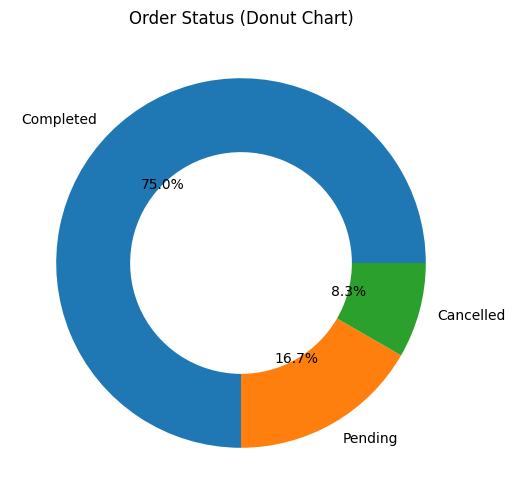

In [15]:
plt.figure(figsize=(6, 6))
plt.pie(
    status_pd["count"],
    labels=status_pd["status"],
    autopct="%1.1f%%",
    wedgeprops={'width': 0.4}
)
plt.title("Order Status (Donut Chart)")
plt.show()

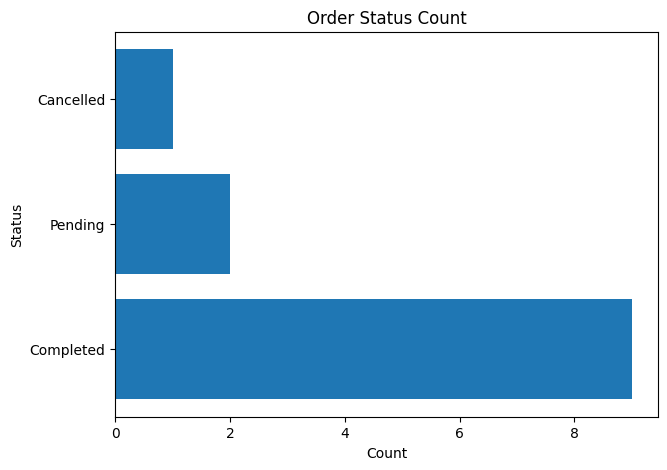

In [16]:
plt.figure(figsize=(7, 5))
plt.barh(status_pd["status"], status_pd["count"])
plt.xlabel("Count")
plt.ylabel("Status")
plt.title("Order Status Count")
plt.show()

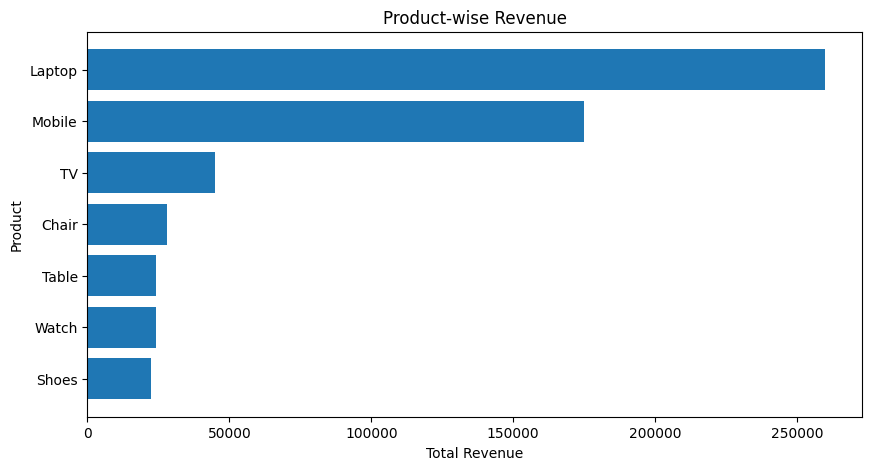

In [18]:
product_revenue_df = df.groupBy("product").agg(
    sum("revenue").alias("total_revenue")
).orderBy(col("total_revenue").desc())

product_pd = product_revenue_df.toPandas()

plt.figure(figsize=(10, 5))
plt.barh(product_pd["product"], product_pd["total_revenue"])
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.title("Product-wise Revenue")
plt.gca().invert_yaxis()
plt.show()

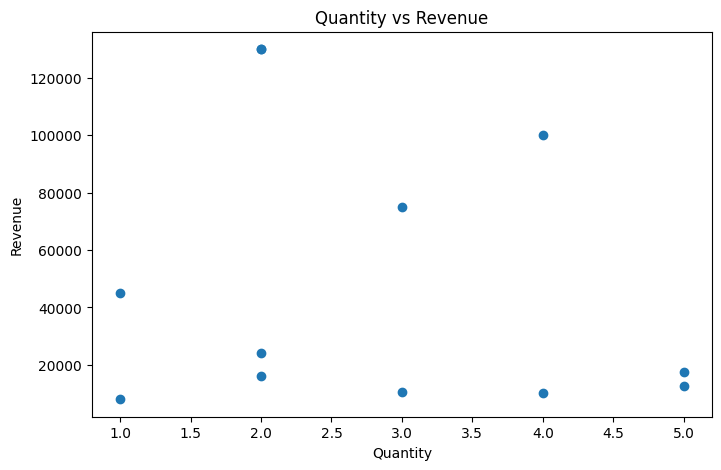

In [19]:
scatter_pd = df.select(
    "quantity",
    "revenue",
    "product"
).toPandas()

plt.figure(figsize=(8, 5))
plt.scatter(scatter_pd["quantity"], scatter_pd["revenue"])
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.title("Quantity vs Revenue")
plt.show()

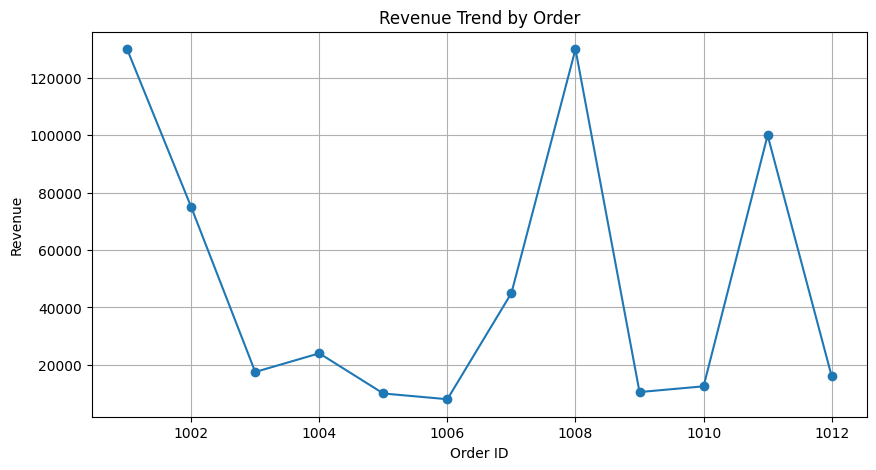

In [20]:
order_pd = df.select(
    "order_id",
    "revenue"
).orderBy("order_id").toPandas()

plt.figure(figsize=(10, 5))
plt.plot(order_pd["order_id"], order_pd["revenue"], marker="o")
plt.xlabel("Order ID")
plt.ylabel("Revenue")
plt.title("Revenue Trend by Order")
plt.grid(True)
plt.show()